In [1]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# import some libraries for training
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt

from helper_modules import phase2_preprocess_data

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# disable some warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="hyperopt")


In [2]:
df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
print(df.shape)
display(df.head())

(105120, 7)


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [3]:
# Try extracting data that has Demand_Response_Flag = 0 and Demand_Response_Capacity_kW != 0.0
df1 = df[
    (df['Demand_Response_Flag']==0) &
    (df['Demand_Response_Capacity_kW'] != 0.0)
].copy(deep=True)
print (df1.shape[0])

df1 = df[
    df['Demand_Response_Flag']==0
].copy(deep=True)
df2 = df1[
    df1['Demand_Response_Capacity_kW'] != 0.0
].copy(deep=True)
print (df2.shape[0])
# We observe that if Demand_Response_Flag = 0, then Demand_Response_Capacity_kW is always 0.0

0
0


,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW,Hour,Day,DOW,Month,Weekday,Minute,Hour_sin,Hour_cos,DOW_sin,DOW_cos,HDD18,CDD22,TempC2,rad_sqrt,rad_log1p,is_daylight,TempC_x_daylight,CDD22_x_daylight,TempC_x_hour_sin,TempC_x_hour_cos,Is_Weekend,Is_Summer,Is_Winter,Is_Afternoon,Is_Evening
0,22.20,0.0,4.8,0,0.0,0,1,1,1,1,0,0.000000,1.000000,0.781831,0.62349,0.0,0.20,492.8400,0.0,0.0,0,0.0,0.0,0.000000,22.200000,0,0,1,0,0
1,22.27,0.0,4.8,0,0.0,0,1,1,1,1,15,0.000000,1.000000,0.781831,0.62349,0.0,0.27,495.9529,0.0,0.0,0,0.0,0.0,0.000000,22.270000,0,0,1,0,0
2,22.35,0.0,4.8,0,0.0,0,1,1,1,1,30,0.000000,1.000000,0.781831,0.62349,0.0,0.35,499.5225,0.0,0.0,0,0.0,0.0,0.000000,22.350000,0,0,1,0,0
3,22.42,0.0,4.8,0,0.0,0,1,1,1,1,45,0.000000,1.000000,0.781831,0.62349,0.0,0.42,502.6564,0.0,0.0,0,0.0,0.0,0.000000,22.420000,0,0,1,0,0
4,22.50,0.0,4.8,0,0.0,1,1,1,1,1,0,0.258819,0.965926,0.781831,0.62349,0.0,0.50,506.2500,0.0,0.0,0,0.0,0.0,5.823429,21.733331,0,0,1,0,0


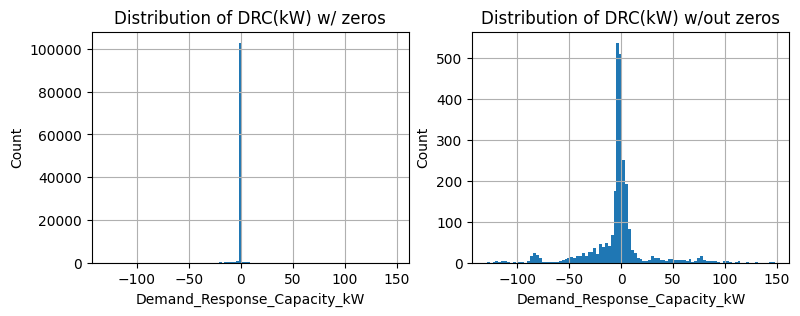

In [4]:
# perform some preprocessing
df = phase2_preprocess_data(df)
display(df.head())

# Visualize the distribution of Demand_Response_Capacity_kW
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(9, 3))
df['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax1)
ax1.set_title('Distribution of DRC(kW) w/ zeros')
ax1.set_xlabel('Demand_Response_Capacity_kW')
ax1.set_ylabel('Count')

df[
    df['Demand_Response_Capacity_kW'] != 0.0
]['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax2)
ax2.set_title('Distribution of DRC(kW) w/out zeros')
ax2.set_xlabel('Demand_Response_Capacity_kW')
ax2.set_ylabel('Count')
plt.show()

In [5]:
# Prepare features and target
X = df.drop(columns=['Demand_Response_Capacity_kW']).values
y = df['Demand_Response_Capacity_kW'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# create labels for those guys that have non-zero Demand_Response_Capacity_kW
is_nz = (y_train != 0).astype(int)

# Define some hyperparameters for XGBoost models
# best_hyperparams = {
#     'clf_colsample_bytree': np.float64(0.9775654796556552),
#     'clf_gamma': np.float64(0.13329075230068158),
#     'clf_learning_rate': np.float64(0.17383113709896234),
#     'clf_max_depth': np.float64(9.0),
#     'clf_n_estimators': np.float64(400.0),
#     'clf_reg_alpha': np.float64(0.17296611578660678),
#     'clf_reg_lambda': np.float64(0.6903217527123108),
#     'clf_subsample': np.float64(0.943381051387595),
#     'reg_gamma': np.float64(0.8078331424847539),
#     'reg_learning_rate': np.float64(0.026378981959377757),
#     'reg_max_depth': np.float64(10.0),
#     'reg_n_estimators': np.float64(200.0),
#     'reg_reg_alpha': np.float64(1.634485075861256),
#     'reg_reg_lambda': np.float64(1.2366919635502922)
# }

best_hyperparams = {
    'clf_colsample_bytree': np.float64(0.7757593611454112),
    'clf_gamma': np.float64(0.46579455318323093),
    'clf_learning_rate': np.float64(0.1310977884396334),
    'clf_max_depth': np.float64(9.0),
    'clf_n_estimators': np.float64(550.0),
    'clf_reg_alpha': np.float64(0.8519182799017948),
    'clf_reg_lambda': np.float64(0.5191667438743655),
    'clf_subsample': np.float64(0.9030212255542556),
    'reg_gamma': np.float64(0.7249560660735597),
    'reg_learning_rate': np.float64(0.1150779304006949),
    'reg_max_depth': np.float64(4.0),
    'reg_n_estimators': np.float64(500.0),
    'reg_reg_alpha': np.float64(1.511074763436688),
    'reg_reg_lambda': np.float64(0.008969525207187294)
}

# 1) Zero vs non-zero:
#    Train XGBoost classifier to identify which observations have zero value for 'Demand_Response_Capacity_kW'
#    So we have 2 classes: 0 (zero) and 1 (non-zero) for 'Demand_Response_Capacity_kW'
clf_nz = xgb.XGBClassifier(
    n_estimators=int(best_hyperparams['clf_n_estimators']), 
    max_depth=int(best_hyperparams['clf_max_depth']), 
    learning_rate=best_hyperparams['clf_learning_rate'],
    subsample=best_hyperparams['clf_subsample'], 
    colsample_bytree=best_hyperparams['clf_colsample_bytree'],
    gamma=best_hyperparams['clf_gamma'],
    reg_lambda=best_hyperparams['clf_reg_lambda'],
    reg_alpha=best_hyperparams['clf_reg_alpha'],
    eval_metric="logloss",
    # handle class imbalance (zeros >> non-zeros)
    scale_pos_weight=(is_nz==0).sum() / max((is_nz==1).sum(), 1),
    random_state=42,
).fit(X_train, is_nz)

# 2) Train XGBoost regressor:
#    only on non-zero observations i.e., we will regress 'Demand_Response_Capacity_kW' on non-zero values
mask = is_nz == 1
reg_nz = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=int(best_hyperparams['reg_n_estimators']),
    max_depth=int(best_hyperparams['reg_max_depth']),
    learning_rate=best_hyperparams['reg_learning_rate'],
    gamma=best_hyperparams['reg_gamma'],
    reg_lambda=best_hyperparams['reg_reg_lambda'],
    reg_alpha=best_hyperparams['reg_reg_alpha'],
    random_state=42
).fit(X_train[mask], y_train[mask])

# Inference: Predict on test set
p_nz = clf_nz.predict_proba(X_test)[:, 1]
mu_nz = reg_nz.predict(X_test)
y_pred = p_nz * mu_nz

In [ ]:
def objective(params):
    # Classifier params
    clf_params = {
        'n_estimators': int(params['clf_n_estimators']),
        'max_depth': int(params['clf_max_depth']),
        'learning_rate': params['clf_learning_rate'],
        'subsample': params['clf_subsample'],
        'colsample_bytree': params['clf_colsample_bytree'],
        'gamma': params['clf_gamma'],
        'reg_lambda': params['clf_reg_lambda'],
        'reg_alpha': params['clf_reg_alpha'],
        'eval_metric': "logloss",
        'scale_pos_weight': (is_nz==0).sum() / max((is_nz==1).sum(), 1),
        'random_state': 42,
        'use_label_encoder': False
    }
    clf = xgb.XGBClassifier(**clf_params)
    clf.fit(X_train, is_nz)
    p_nz = clf.predict_proba(X_test)[:, 1]

    # Regressor params
    reg_params = {
        'objective': 'reg:squarederror',
        'n_estimators': int(params['reg_n_estimators']),
        'max_depth': int(params['reg_max_depth']),
        'learning_rate': params['reg_learning_rate'],
        'gamma': params['reg_gamma'],
        'reg_lambda': params['reg_reg_lambda'],
        'reg_alpha': params['reg_reg_alpha'],
        'random_state': 42
    }
    reg = xgb.XGBRegressor(**reg_params)
    reg.fit(X_train[mask], y_train[mask])
    mu_nz = reg.predict(X_test)

    y_pred = p_nz * mu_nz
    score = mean_squared_error(y_test, y_pred)
    return {'loss': score, 'status': STATUS_OK}


space = {
    'clf_n_estimators': hp.quniform('clf_n_estimators', 100, 800, 50),
    'clf_max_depth': hp.quniform('clf_max_depth', 3, 10, 1),
    'clf_learning_rate': hp.uniform('clf_learning_rate', 0.01, 0.2),
    'clf_subsample': hp.uniform('clf_subsample', 0.6, 1.0),
    'clf_colsample_bytree': hp.uniform('clf_colsample_bytree', 0.6, 1.0),
    'clf_gamma': hp.uniform('clf_gamma', 0, 1),
    'clf_reg_lambda': hp.uniform('clf_reg_lambda', 0, 2),
    'clf_reg_alpha': hp.uniform('clf_reg_alpha', 0, 2),
    'reg_n_estimators': hp.quniform('reg_n_estimators', 100, 800, 50),
    'reg_max_depth': hp.quniform('reg_max_depth', 3, 10, 1),
    'reg_learning_rate': hp.uniform('reg_learning_rate', 0.01, 0.2),
    'reg_gamma': hp.uniform('reg_gamma', 0, 1),
    'reg_reg_lambda': hp.uniform('reg_reg_lambda', 0, 2),
    'reg_reg_alpha': hp.uniform('reg_reg_alpha', 0, 2),
}

use_hyperopt = False
if use_hyperopt:
    trials = Trials()
    best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=50, trials=trials)
    print("Best hyperparameters:", best)
    sys.exit()

In [7]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1732
MSE: 5.2925
RMSE: 2.3006


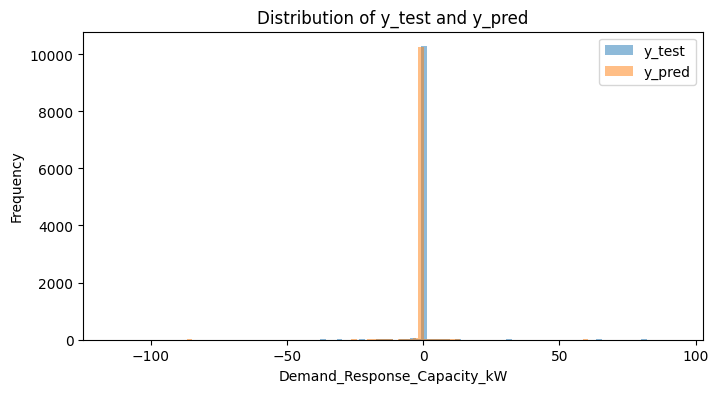

In [8]:
plt.figure(figsize=(8,4))
plt.hist(y_test, bins=100, alpha=0.5, label='y_test')
plt.hist(y_pred, bins=100, alpha=0.5, label='y_pred')
plt.legend()
plt.xlabel('Demand_Response_Capacity_kW')
plt.ylabel('Frequency')
plt.title('Distribution of y_test and y_pred')
plt.show()

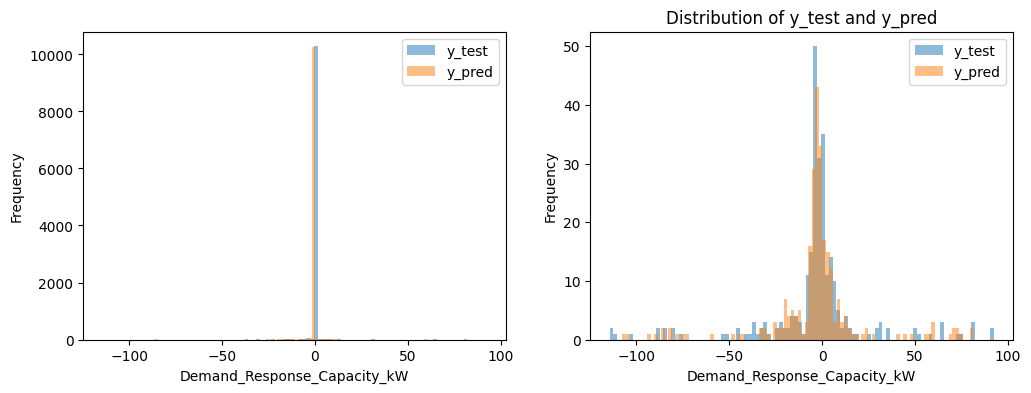

In [9]:
# Remove zeros in y_test and corresponding entries in y_pred
mask_nonzero = y_test != 0
y_test_nz = y_test[mask_nonzero]
y_pred_nz = y_pred[mask_nonzero]


fig, (ax1,ax2) = plt.subplots(1,2,figsize=(12,4))
ax1.hist(y_test, bins=100, alpha=0.5, label='y_test')
ax1.hist(y_pred, bins=100, alpha=0.5, label='y_pred')
ax1.legend()
ax1.set_xlabel('Demand_Response_Capacity_kW')
ax1.set_ylabel('Frequency')

ax2.hist(y_test_nz, bins=100, alpha=0.5, label='y_test')
ax2.hist(y_pred_nz, bins=100, alpha=0.5, label='y_pred')
ax2.legend()
ax2.set_xlabel('Demand_Response_Capacity_kW')
ax2.set_ylabel('Frequency')

plt.title('Distribution of y_test and y_pred')
plt.show()

In [10]:
# Save models
joblib.dump(clf_nz, './models/phase2_xgb_clf_nz_model.pkl')
joblib.dump(reg_nz, './models/phase2_xgb_reg_nz_model.pkl')
print("Models saved.")

Models saved.
